# Exploración de Datos — Llegadas y Salidas de Vehículos, Terminal de Transporte

**Curso:** Modelos y Simulación de Sistemas I — Proyecto integrador, Fase 1
**Dataset:** [Llegadas y Salidas de Vehículos de la Terminal de Transporte](https://www.datos.gov.co/Transporte/Llegada-y-Salidas-de-Veh-culos-de-la-Terminal-de-T/pfsr-mdyi/about_data) — Datos Abiertos Colombia (recurso `pfsr-mdyi`)
**Problema:** predecir la **duración de un viaje** (`duracion_viaje_horas`) — regresión de tipo ETA (tiempo estimado de llegada).

## Orden de este notebook

La exploración se hace sobre el dato **crudo** (tal como llega, sin descartar ni transformar columnas) antes de derivar y analizar la variable objetivo, para que cualquier decisión de limpieza quede respaldada por evidencia y no por suposición. Este notebook sigue esa secuencia en dos fases:

- **Fase A — Exploración cruda** (Pasos 1 a 5): dimensiones, nulos, tipos de datos, categóricas, patrones de nulos. Se trabaja sobre las 12 columnas originales del dataset, sin excepción, incluidas las que a primera vista parecen no aportar (como `estado`).
- **Fase B — Variables numéricas** (Pasos 6 a 8): se derivan las 3 variables numéricas que no vienen dadas (`duracion_viaje_horas` el objetivo, `hora_salida_decimal`, `dia_semana`), cada una justificada, y se hace la inspección numérica y de correlaciones una sola vez, ya con el panorama completo.

Las decisiones de limpieza (qué columnas se eliminan, cómo se tratan los nulos, qué categorías se agrupan) **no se toman en este notebook** — se toman después, con la evidencia recogida aquí como respaldo.


## Configuración e imports

In [1]:
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

BASE_URL = "https://www.datos.gov.co/resource/pfsr-mdyi.json"

# Las 12 columnas originales del recurso (verificadas contra los metadatos del dataset).
COLUMNS = [
    "estado", "nombre_sucursal", "empresa", "fecha_salida",
    "fecha_hora_salida_origen", "fecha_llegada", "hora_de_llegada",
    "ruta_origen", "ruta_destino", "subregi_n", "clase_veh_culo", "pasajeros",
]

RAW_SAMPLE_PATH = "../data/raw/muestra_cruda.csv"


# FASE A — Exploración cruda (sin modificar ni descartar nada)

Todo lo que sigue trabaja sobre las 12 columnas originales, exactamente como las entrega la API. No se deriva ni se elimina ninguna columna en esta fase.


## Paso 1 — Cargar los datos e inspeccionar dimensiones

**Qué se hace:** traer los datos desde el endpoint, **sin filtrar por clase de vehículo** (el alcance incluye BUS, MICROBUS, CAMIONETA, AUTOMOVIL y DUO BUS), y revisar dimensiones, columnas y primeras filas.

**Tamaño de la muestra:** el dataset completo tiene 2.617.130 filas (verificado previamente vía agregaciones SoQL sobre la tabla completa). Para que sea manejable en un computador personal se trabaja con una muestra de ~180.000 filas, **estratificada por `clase_veh_culo` y por año** (2023, 2024, 2025 — los años con volumen real; los ~30 registros sueltos de años atípicos como 2002-2012 o 2029 quedan naturalmente excluidos), para conservar las proporciones reales del dataset completo y no perder representatividad de las clases más pequeñas (AUTOMOVIL, DUO BUS).


In [2]:
# 1a. Tamaño real de cada combinación (clase de vehículo x año), calculado sobre el dataset COMPLETO
# (agregación en el servidor, no se descargan las 2.6M filas para esto).
strata_query = '''
SELECT `clase_veh_culo`, date_extract_y(`fecha_salida`) as anio, count(*) as n
WHERE date_extract_y(`fecha_salida`) IN (2023, 2024, 2025)
GROUP BY `clase_veh_culo`, anio
ORDER BY n DESC
'''
r = requests.get(BASE_URL, params={"$query": strata_query}, timeout=120)
r.raise_for_status()
strata = pd.DataFrame(r.json())
strata["n"] = strata["n"].astype(int)
strata["clase_veh_culo"] = strata["clase_veh_culo"].str.upper().str.strip()
strata = strata.dropna(subset=["clase_veh_culo", "anio"])
strata = strata.groupby(["clase_veh_culo", "anio"], as_index=False)["n"].sum()
strata


,clase_veh_culo,anio,n
0,AUTOMOVIL,2023,13467
1,AUTOMOVIL,2024,14214
2,AUTOMOVIL,2025,12510
3,BUS,2023,400050
4,BUS,2024,456840
5,BUS,2025,466441
6,CAMIONETA,2023,166738
7,CAMIONETA,2024,176663
8,CAMIONETA,2025,182578
9,DUO BUS,2023,4413


In [3]:
# 1b. Tamaño de muestra proporcional por estrato, para un total objetivo de ~180,000 filas
TARGET_TOTAL = 180_000
total_n = strata["n"].sum()
strata["sample_n"] = (strata["n"] / total_n * TARGET_TOTAL).round().astype(int)
strata["sample_n"] = strata["sample_n"].clip(lower=1)
print(f"Total real (2023-2025, todas las clases): {total_n:,}")
print(f"Total a muestrear: {strata['sample_n'].sum():,}")
strata.sort_values("sample_n", ascending=False)


Total real (2023-2025, todas las clases): 2,617,078
Total a muestrear: 180,000


,clase_veh_culo,anio,n,sample_n
5,BUS,2025,466441,32081
4,BUS,2024,456840,31421
3,BUS,2023,400050,27515
14,MICROBUS,2025,250199,17208
13,MICROBUS,2024,246635,16963
12,MICROBUS,2023,219614,15105
8,CAMIONETA,2025,182578,12558
7,CAMIONETA,2024,176663,12151
6,CAMIONETA,2023,166738,11468
1,AUTOMOVIL,2024,14214,978


In [4]:
def soql_select(where_clause, limit, offset=0, timeout=120):
    select_cols = ", ".join(f"`{c}`" for c in COLUMNS)
    query = f"SELECT {select_cols} WHERE {where_clause} LIMIT {limit} OFFSET {offset}"
    r = requests.get(BASE_URL, params={"$query": query}, timeout=timeout)
    r.raise_for_status()
    return r.json()


def fetch_stratum(clase, anio, n_rows, page_size=50_000):
    where = (
        f'caseless_one_of(`clase_veh_culo`, "{clase}") '
        f"AND date_extract_y(`fecha_salida`) = {anio}"
    )
    rows, offset = [], 0
    while len(rows) < n_rows:
        batch = soql_select(where, min(page_size, n_rows - len(rows)), offset)
        if not batch:
            break
        rows.extend(batch)
        offset += len(batch)
        if len(batch) < page_size:
            break
    return rows


In [5]:
# 1c. Descarga estratificada (una consulta por combinación clase x año)
all_rows = []
for _, row in strata.iterrows():
    batch = fetch_stratum(row["clase_veh_culo"], int(row["anio"]), int(row["sample_n"]))
    all_rows.extend(batch)
    print(f"{row['clase_veh_culo']:<12} {int(row['anio'])}  ->  {len(batch):>6,} filas")
    time.sleep(0.2)  # no saturar la API pública

df_raw = pd.DataFrame(all_rows)
print("\nTotal descargado:", len(df_raw))


AUTOMOVIL    2023  ->     926 filas


AUTOMOVIL    2024  ->     978 filas


AUTOMOVIL    2025  ->     860 filas


BUS          2023  ->  27,515 filas


BUS          2024  ->  31,421 filas


...

DUO BUS      2025  ->     218 filas


MICROBUS     2023  ->  15,105 filas


MICROBUS     2024  ->  16,963 filas


MICROBUS     2025  ->  17,208 filas



Total descargado: 180000


In [6]:
# Guardar la muestra cruda localmente (no se versiona en git, ver .gitignore) para no
# tener que repetir la descarga cada vez que se re-ejecute el notebook.
import os
os.makedirs(os.path.dirname(RAW_SAMPLE_PATH), exist_ok=True)
df_raw.to_csv(RAW_SAMPLE_PATH, index=False)
print(f"Guardado en {RAW_SAMPLE_PATH}")


Guardado en ../data/raw/muestra_cruda.csv


In [7]:
print("Dimensiones (filas, columnas):", df_raw.shape)
print("\nColumnas:", list(df_raw.columns))
df_raw.head()


Dimensiones (filas, columnas): (180000, 12)

Columnas: ['estado', 'nombre_sucursal', 'empresa', 'fecha_salida', 'fecha_hora_salida_origen', 'fecha_llegada', 'hora_de_llegada', 'ruta_origen', 'ruta_destino', 'subregi_n', 'clase_veh_culo', 'pasajeros']


,estado,nombre_sucursal,empresa,fecha_salida,fecha_hora_salida_origen,fecha_llegada,hora_de_llegada,ruta_origen,ruta_destino,subregi_n,clase_veh_culo,pasajeros
0,Llegada,Terminal del Norte,EXPRE - BELMIRA S.A.,2023-02-01T00:00:00.000,2023-02-01T05:00:00.000,2023-02-01T00:00:00.000,2023-02-01T05:50:00.000,SAN PEDRO DE LOS MILAGROS,MEDELLIN,Norte,AUTOMOVIL,1
1,Llegada,Terminal del Sur,COTRACIBOL,2023-02-01T00:00:00.000,2023-02-01T05:00:00.000,2023-02-01T00:00:00.000,2023-02-01T07:10:00.000,BOLIVAR,MEDELLIN,Sur,AUTOMOVIL,1
2,Llegada,Terminal del Sur,FLOTA FREDONIA S.A.S,2023-02-01T00:00:00.000,2023-02-01T06:00:00.000,2023-02-01T00:00:00.000,2023-02-01T07:41:00.000,FREDONIA,MEDELLIN,Sur,AUTOMOVIL,1
3,Llegada,Terminal del Norte,JUAN B VASQUEZ,2023-02-01T00:00:00.000,2023-02-01T05:15:00.000,2023-02-01T00:00:00.000,2023-02-01T07:46:00.000,GUADALUPE,MEDELLIN,Norte,AUTOMOVIL,2
4,Llegada,Terminal del Sur,COTRACIBOL,2023-02-01T00:00:00.000,2023-02-01T05:00:00.000,2023-02-01T00:00:00.000,2023-02-01T07:58:00.000,BOLIVAR,MEDELLIN,Sur,AUTOMOVIL,1


## Paso 2 — Conteo rápido de valores faltantes por columna

Chequeo rápido de calidad de datos, sobre las 12 columnas originales.


In [8]:
nulls = pd.DataFrame({
    "nulos": df_raw.isnull().sum(),
    "pct_nulos": (df_raw.isnull().mean() * 100).round(3),
}).sort_values("pct_nulos", ascending=False)
nulls


,nulos,pct_nulos
fecha_hora_salida_origen,38872,21.596
empresa,12,0.007
nombre_sucursal,0,0.000
estado,0,0.000
fecha_salida,0,0.000
fecha_llegada,0,0.000
hora_de_llegada,0,0.000
ruta_origen,0,0.000
ruta_destino,0,0.000
subregi_n,0,0.000


**Lectura:** `fecha_hora_salida_origen` sale con **21.6%** de nulos en esta muestra, no el ~33% medido antes sobre el dataset completo. La diferencia se explica por el diseño de la muestra: aquí se tomó una cantidad similar de filas por cada año (2023/2024/2025), mientras que el nulo real está concentrado casi todo en 2024 (ver Paso 5) — al balancear los años, el promedio de la muestra se diluye respecto al del dataset completo (donde 2024 pesa más). El resto de columnas está en 0% o casi 0%, igual que en el dataset completo.


## Paso 3 — Descubrir los tipos de datos (*Discover data types*)

Se revisa qué tipo trae realmente pandas al leer cada columna, y se corrige el reconocimiento de tipos donde haga falta (esto es **reconocer** el tipo real del dato, no derivar información nueva).


In [9]:
print("Tipos ANTES de reconocer fechas/números:")
df_raw.dtypes


Tipos ANTES de reconocer fechas/números:


estado                      str
nombre_sucursal             str
empresa                     str
fecha_salida                str
fecha_hora_salida_origen    str
fecha_llegada               str
hora_de_llegada             str
ruta_origen                 str
ruta_destino                str
subregi_n                   str
clase_veh_culo              str
pasajeros                   str
dtype: object

In [10]:
df = df_raw.copy()

date_cols = ["fecha_salida", "fecha_hora_salida_origen", "fecha_llegada", "hora_de_llegada"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df["pasajeros"] = pd.to_numeric(df["pasajeros"], errors="coerce")

categorical_cols = ["estado", "nombre_sucursal", "empresa", "ruta_origen",
                    "ruta_destino", "subregi_n", "clase_veh_culo"]
for c in categorical_cols:
    df[c] = df[c].astype("category")

print("Tipos DESPUÉS de reconocer fechas/números:")
df.dtypes


Tipos DESPUÉS de reconocer fechas/números:


estado                            category
nombre_sucursal                   category
empresa                           category
fecha_salida                datetime64[us]
fecha_hora_salida_origen    datetime64[us]
fecha_llegada               datetime64[us]
hora_de_llegada             datetime64[us]
ruta_origen                       category
ruta_destino                      category
subregi_n                         category
clase_veh_culo                    category
pasajeros                            int64
dtype: object

**Lectura esperada:** `pasajeros` debería pasar de texto a numérico (ya se había visto en la exploración inicial vía API que llegaba como string, ej. `"8"`). Las 4 columnas de fecha deberían pasar a `datetime64`. El resto queda como categórico — de las 12 columnas originales, **solo `pasajeros` es genuinamente numérica en este punto**; por eso "Inspeccionar columnas numéricas" y "Correlaciones" se dejaron para la Fase B, cuando existan más numéricas con las que valga la pena hacer esos dos pasos.


## Paso 4 — Inspeccionar variables categóricas (*Inspect categorical variables*)

Se analizan **todas** las categóricas originales, incluida `estado` — aunque ya se sospecha, del análisis previo sobre el dataset completo, que es constante. La idea es demostrarlo aquí con evidencia (no descartarla "porque ya se sabía"), para poder documentar después esa evidencia como justificación de por qué se elimina.


In [11]:
for c in categorical_cols:
    print(f"\n=== {c} (cardinalidad: {df[c].nunique()}) ===")
    print(df[c].value_counts(dropna=False).head(10))



=== estado (cardinalidad: 2) ===
estado
LLEGADA    124693
Llegada     55307
Name: count, dtype: int64

=== nombre_sucursal (cardinalidad: 4) ===
nombre_sucursal
Terminal del Norte    87229
TERMINAL DEL NORTE    44951
Terminal del Sur      31003
TERMINAL DEL SUR      16817
Name: count, dtype: int64

=== empresa (cardinalidad: 137) ===
empresa
COOPETRANSA                                   12073
COONORTE                                      11995
RAPIDO MEDELLIN RIONEGRO S.A.                  9313
SOTRAURABA                                     8274
TRANSORIENTE                                   7665
TRANS GOMEZ HERNANDEZ                          7588
TRANSUNIDOS                                    7186
EXPRE - BELMIRA S.A.                           6999
SOTRAMAR                                       5598
SOTRASANVICENTE & GUATAPE LA PIEDRA S.C.A.     5332
Name: count, dtype: int64

=== ruta_origen (cardinalidad: 375) ===
ruta_origen
RIONEGRO                              14253
RIONEGRO-MED

subregi_n
Oriente      46677
Norte        34638
ORIENTE      23250
Sur          18611
NORTE        18529
Occidente    10788
SUR          10067
Centro        7518
OCCIDENTE     5796
CENTRO        4126
Name: count, dtype: int64

=== clase_veh_culo (cardinalidad: 5) ===
clase_veh_culo
BUS          91017
MICROBUS     49276
CAMIONETA    36177
AUTOMOVIL     2764
DUO BUS        766
Name: count, dtype: int64


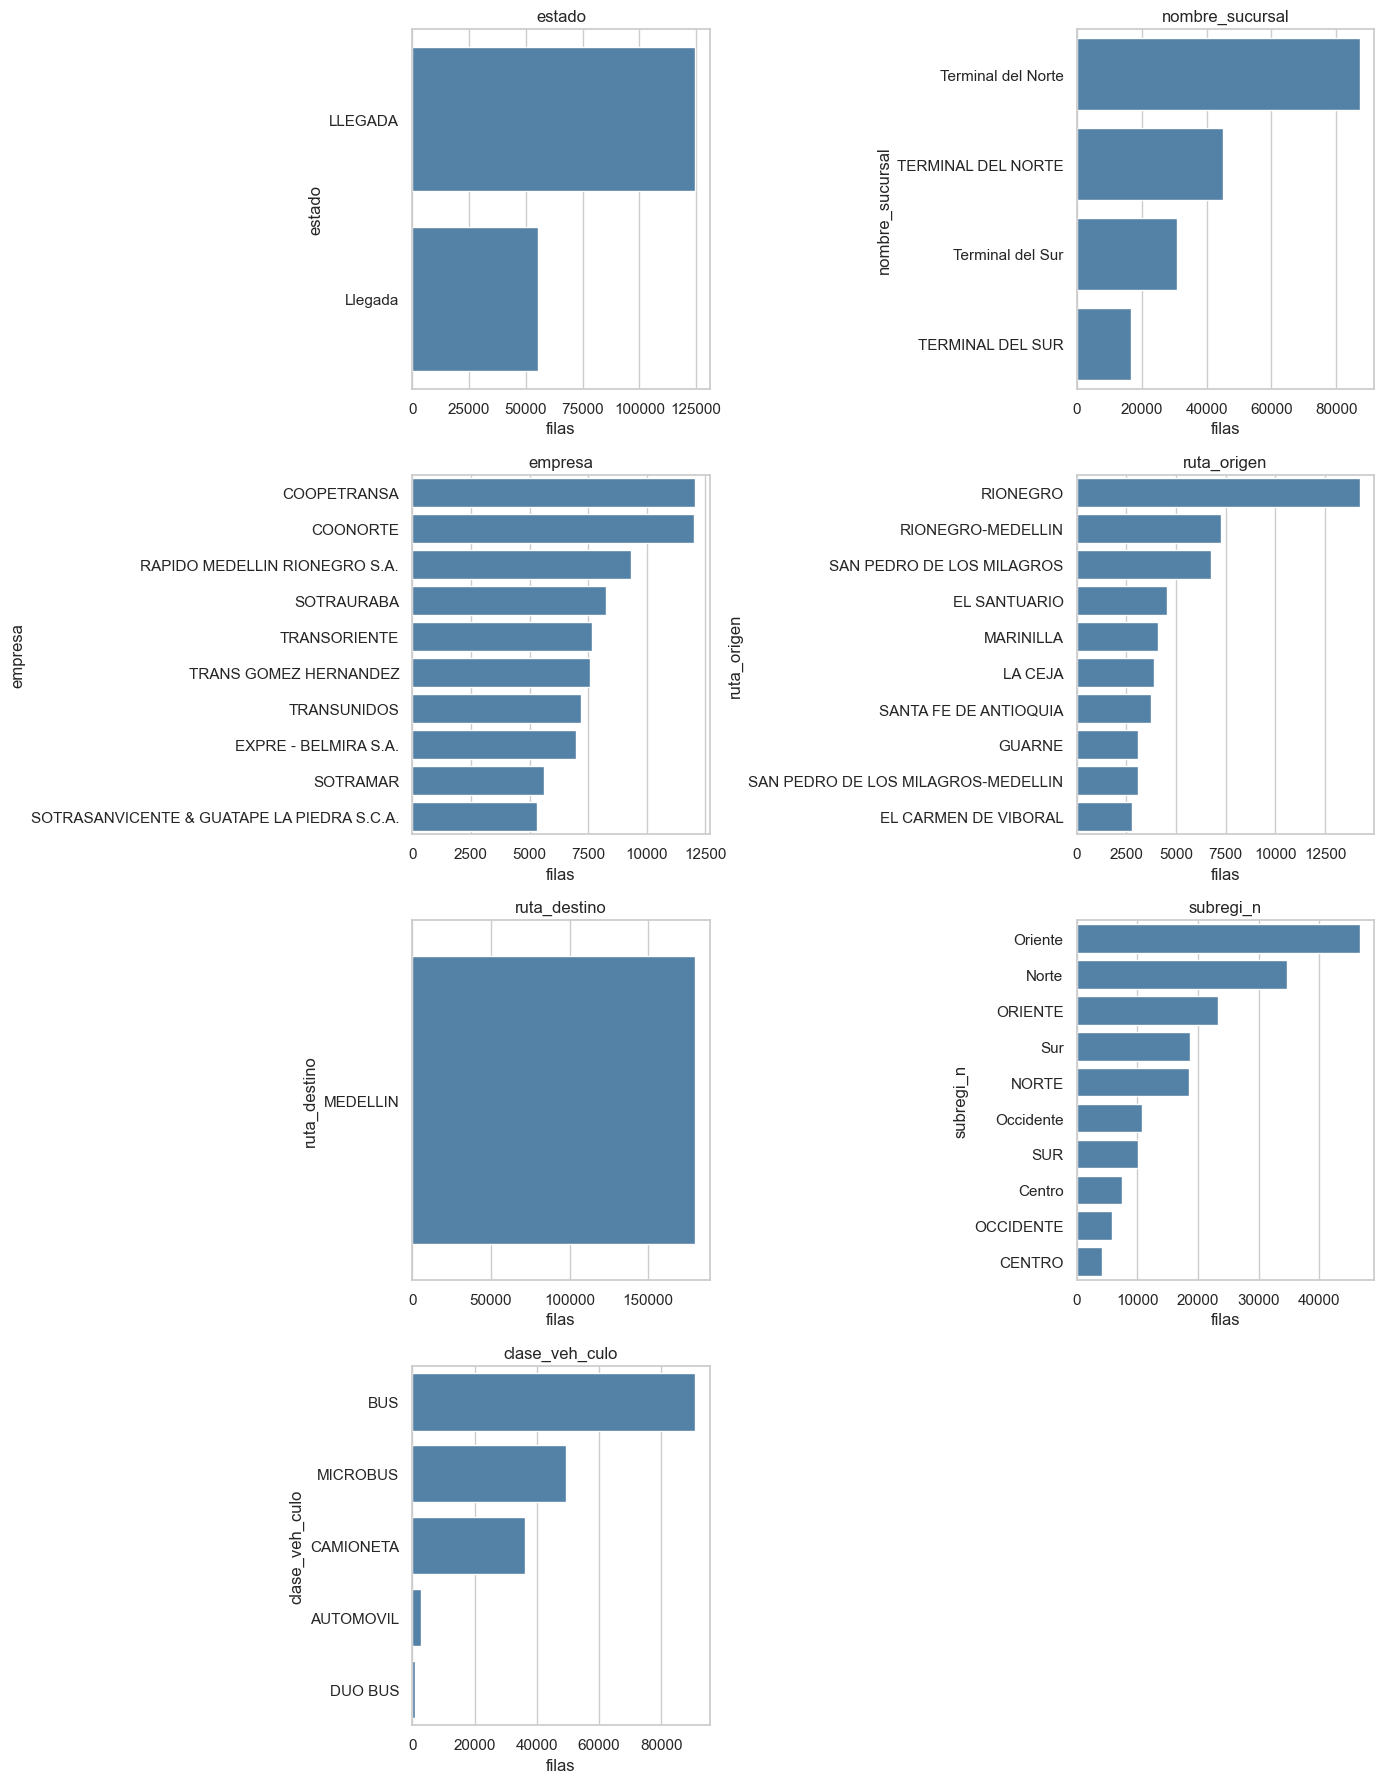

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for ax, c in zip(axes, categorical_cols):
    top = df[c].value_counts(dropna=False).head(10)
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color="steelblue")
    ax.set_title(c)
    ax.set_xlabel("filas")
for ax in axes[len(categorical_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Hallazgos confirmados:**
- `estado`: cardinalidad 2, pero es la misma categoría con inconsistencia de mayúsculas ("LLEGADA"/"Llegada") — varianza cero, no aporta nada como predictora ni como objetivo. Se elimina en la fase de preparación.
- `clase_veh_culo`: 5 categorías reales con variabilidad genuina (BUS, MICROBUS, CAMIONETA, AUTOMOVIL, DUO BUS) — predictora candidata válida.
- **`nombre_sucursal`: cardinalidad 4, NO 1 como se sospechaba antes de esta exploración.** Son en realidad 2 terminales reales ("Terminal del Norte" y "Terminal del Sur"), cada uno duplicado por una inconsistencia de mayúsculas/minúsculas. Corrige una suposición anterior ("el dataset parece venir de una sola terminal") — queda como predictora candidata válida, normalizando antes las mayúsculas.
- **`ruta_destino`: cardinalidad 1 — "MEDELLIN" en el 100% de las filas.** Hallazgo nuevo, no anticipado: tiene sentido porque el dataset solo contiene registros de llegada (`estado`) y ambas terminales están en Medellín. Varianza cero — se elimina en la fase de preparación, igual que `estado`.
- `empresa` (137 categorías) y `ruta_origen` (375 categorías): cardinalidad alta confirmada — a definir después cómo codificarlas (agrupar categorías raras, u otra técnica).
- `subregi_n`: cardinalidad 10, pero son solo 5 subregiones reales duplicadas por la misma inconsistencia de mayúsculas que las demás categóricas (Oriente/ORIENTE, Norte/NORTE, Sur/SUR, Occidente/OCCIDENTE, Centro/CENTRO) — normalizar mayúsculas en la preparación.


## Paso 5 — Análisis de valores faltantes (*Missing values in columns*)

Análisis en profundidad de los nulos (a diferencia del conteo rápido del Paso 2), enfocado en `fecha_hora_salida_origen`, la única columna con nulos relevantes (~33%).


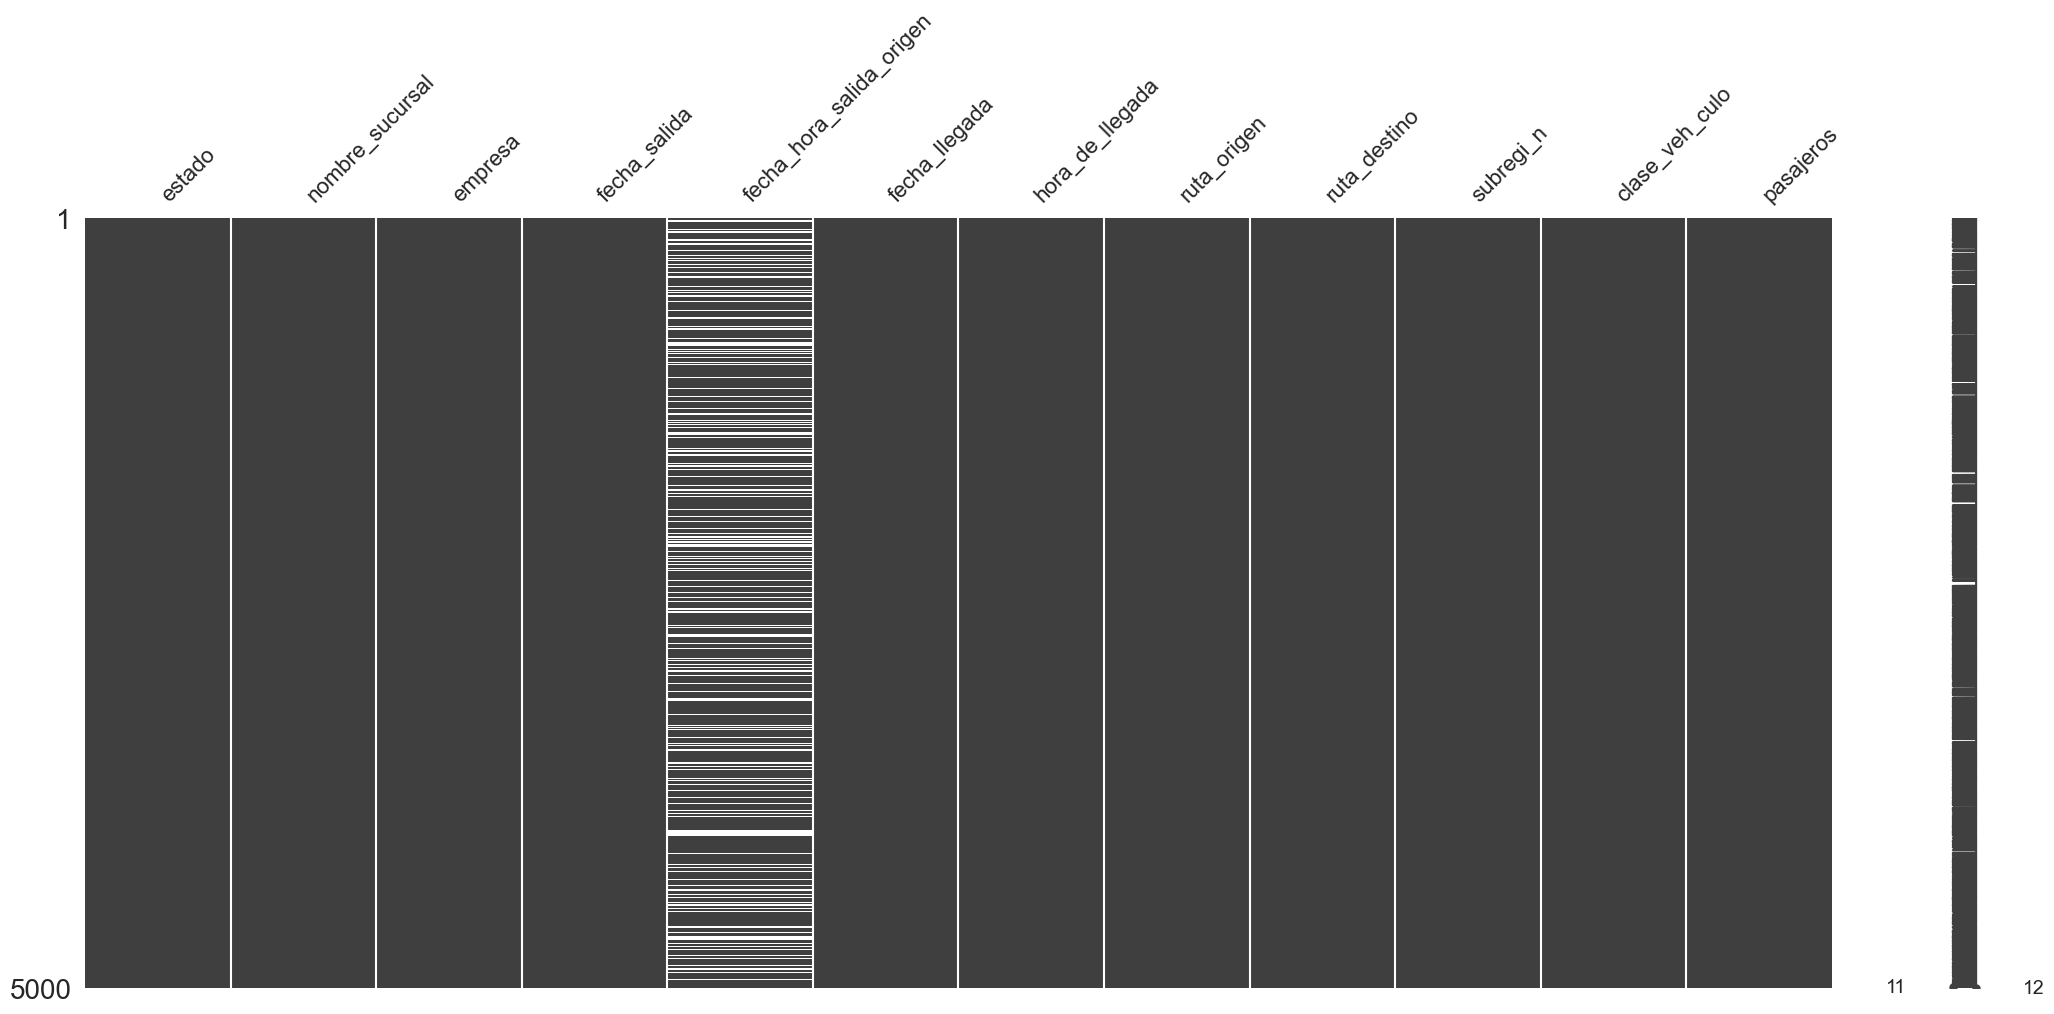

In [13]:
msno.matrix(df.sample(min(5000, len(df)), random_state=42))
plt.show()


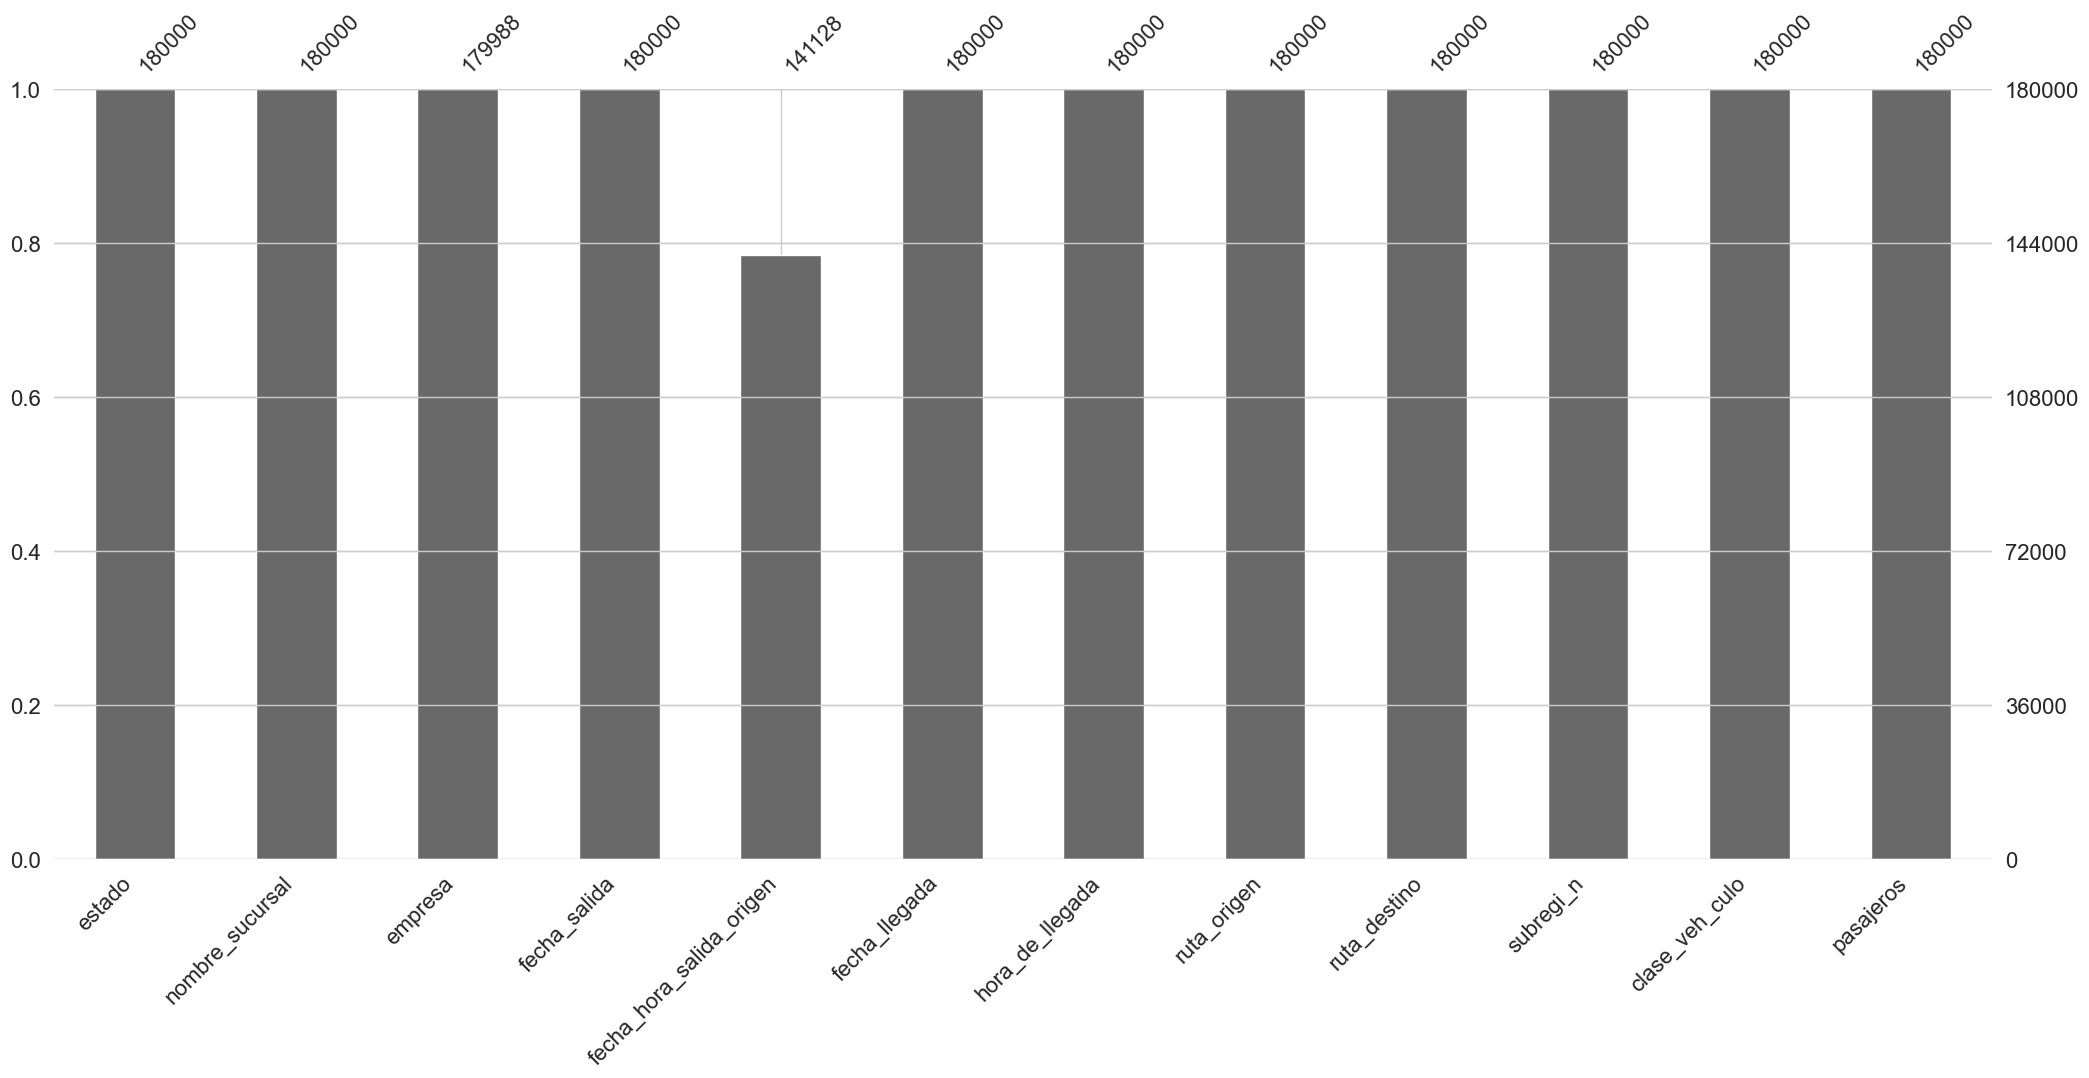

In [14]:
msno.bar(df)
plt.show()


In [15]:
# Cruce del patrón de nulos contra el año, para distinguir MCAR de MAR
df["_anio_salida"] = df["fecha_salida"].dt.year
tabla_nulos_por_anio = (
    df.assign(falta_hora_origen=df["fecha_hora_salida_origen"].isna())
    .groupby("_anio_salida")["falta_hora_origen"]
    .mean()
    .mul(100)
    .round(2)
)
tabla_nulos_por_anio


_anio_salida
2023     0.00
2024    62.94
2025     0.00
Name: falta_hora_origen, dtype: float64

**Teoría — mecanismos de datos faltantes:**
- **MCAR** (Missing Completely At Random): la probabilidad de faltar no depende de nada.
- **MAR** (Missing At Random): depende de otra variable observada (ej. del año).
- **MNAR** (Missing Not At Random): depende del propio valor que falta.

**Confirmado:** el porcentaje de nulos de `fecha_hora_salida_origen` es 0.00% en 2023, **62.94% en 2024**, y 0.00% en 2025 — depende fuertemente del año, una variable observada. Esto **descarta MCAR** y confirma **MAR**: la estrategia de imputación no debería ser una media/moda global, sino algo sensible al año (o, como se ve en el Paso 6, usar `fecha_salida` como respaldo cuando falta `fecha_hora_salida_origen`, que es justamente lo que ocurre en 2024).


# FASE B — Derivar y analizar las variables numéricas

Solo ahora, con el dato crudo ya entendido (Fase A), se justifican y construyen las variables numéricas que no vienen dadas.


## Paso 6 — Derivar las variables numéricas

Antes de fijar la fórmula del objetivo, se valida un supuesto que se venía dando por hecho: que `fecha_salida` y `fecha_llegada` traen la fecha **y** la hora real del viaje. Este chequeo es diagnóstico — sigue siendo evidencia, no una decisión de limpieza.

In [16]:
def pct_medianoche(s):
    return (s.dt.time.astype(str) == "00:00:00").mean() * 100

print("% de filas en medianoche (00:00:00), por columna de fecha:")
for c in ["fecha_salida", "fecha_hora_salida_origen", "fecha_llegada", "hora_de_llegada"]:
    print(f"  {c:<28} {pct_medianoche(df[c]):6.3f}%   (nulos: {df[c].isna().mean()*100:.2f}%)")

print("\nPor año de fecha_salida:")
print((df.assign(medianoche=df["fecha_salida"].dt.time.astype(str) == "00:00:00",
                  anio=df["fecha_salida"].dt.year)
        .groupby("anio")["medianoche"].mean() * 100).round(2))

print("\nPor nombre_sucursal:")
print((df.assign(medianoche=df["fecha_salida"].dt.time.astype(str) == "00:00:00")
        .groupby("nombre_sucursal", observed=True)["medianoche"].mean() * 100).round(2))


% de filas en medianoche (00:00:00), por columna de fecha:


  fecha_salida                 65.714%   (nulos: 0.00%)


  fecha_hora_salida_origen      0.063%   (nulos: 21.60%)


  fecha_llegada                65.689%   (nulos: 0.00%)


  hora_de_llegada               0.012%   (nulos: 0.00%)

Por año de fecha_salida:


anio
2023     99.98
2024      0.09
2025    100.00
Name: medianoche, dtype: float64

Por nombre_sucursal:


nombre_sucursal
TERMINAL DEL NORTE      0.08
TERMINAL DEL SUR        0.12
Terminal del Norte    100.00
Terminal del Sur      100.00
Name: medianoche, dtype: float64


**Hallazgo:** `fecha_salida` y `fecha_llegada` están truncadas a medianoche (`00:00:00`) en cerca del **65.7%** de las filas — en más de la mitad de los casos **no** traen la hora real, solo la fecha. En cambio, `fecha_hora_salida_origen` y `hora_de_llegada` casi nunca están en medianoche (~0.06% y ~0.01%).

El patrón coincide exactamente con dos variables ya vistas en la Fase A:
- **Año** (Paso 1/5): 2023 y 2025 ≈ 100% medianoche; 2024 ≈ 0.09% medianoche.
- **Variante de mayúsculas de `nombre_sucursal`** (Paso 4): "Terminal del Norte/Sur" (con minúsculas) ≈ 100% medianoche; "TERMINAL DEL NORTE/SUR" (mayúsculas) ≈ 0.08% medianoche.

Esto sugiere **dos sistemas o convenciones de captura distintos**: uno (2023/2025, terminal en minúsculas) donde `fecha_salida`/`fecha_llegada` solo guardan la fecha y la hora real vive aparte, en `fecha_hora_salida_origen`/`hora_de_llegada`; y otro (2024, terminal en mayúsculas) donde `fecha_salida`/`fecha_llegada` sí traen la hora completa — coincidiendo, además, con que `fecha_hora_salida_origen` es precisamente la que más nulos tiene en 2024 (Paso 5): en ese período probablemente ya no hacía falta diligenciarla aparte, porque `fecha_salida` bastaba.

**Consecuencia:** calcular `fecha_llegada - fecha_salida` directamente da una duración de `0` para ~65.7% de los viajes — no es una medida real, es un artefacto del formato de captura. La corrección:

- **Salida real:** `fecha_hora_salida_origen` si existe; si no, `fecha_salida` como respaldo (`fillna`) — porque cuando falta la primera (sobre todo en 2024), es justamente porque la segunda ya trae la hora completa.
- **Llegada real:** `hora_de_llegada` directamente (0% nulos, prácticamente nunca en medianoche).

```
salida_real = fecha_hora_salida_origen.fillna(fecha_salida)
llegada_real = hora_de_llegada
duracion_viaje_horas = (llegada_real - salida_real) en horas
```

**Aclaración importante — esto NO es imputación estadística.** No se está "adivinando" el valor faltante con una media, mediana o moda (eso sería inventar un dato que no existe). Se está sustituyendo con la **otra columna que, en esos casos específicos, ya tiene el dato real** capturado por el otro sistema. Por eso el resultado (`salida_real`) queda con 0% de nulos y solo 0.078% en medianoche — mejor que cualquiera de las dos columnas por separado, sin inventar ningún valor.

**Esto resuelve el uso de `fecha_hora_salida_origen` *dentro de la fórmula* del objetivo y de `hora_salida_decimal` — pero NO resuelve qué hacer con ella como predictora independiente**, con su ~21-33% de nulos propios si se usa sola. Esa es una decisión distinta, todavía pendiente para la fase de preparación (ver resumen final del notebook).

**`hora_salida_decimal` también se deriva de `salida_real`, no de `fecha_salida` directamente** — por la misma razón: si se usara `fecha_salida` sin corregir, el 65.7% de las filas mostraría una hora de salida de `00:00`, que sería falsa.

**`dia_semana` sí se deriva de `fecha_salida` directamente (sin corregir)** — el problema de medianoche afecta solo la *hora*, no la fecha/día calendario, que se asume igual de confiable en ambos sistemas de captura.

**Justificación de las 3 variables:**

**a) `duracion_viaje_horas`** (objetivo) — con la fórmula corregida de arriba, condicionada a que la Fase A confirmó que las 4 columnas de fecha involucradas están prácticamente completas (0% u ~21% de nulos, cubierto por el `fillna`).

**b) `hora_salida_decimal`** (ej. `14.5` para las 2:30pm) — se extrae la hora del día de `salida_real` porque es razonable que influya en la duración (tráfico, hora pico), no la fecha completa. Se guarda en decimal, y no como entero, para no perder la precisión de los minutos (un viaje a las 7:58 puede comportarse distinto a uno a las 8:02, aunque ambos redondeen a la misma hora entera).

**c) `dia_semana`** (0=lunes … 6=domingo) — se supone razonable que día laboral vs. fin de semana afecte la duración (tráfico, volumen de pasajeros).

Estas siguen siendo transformaciones mecánicas y justificadas — no decisiones de limpieza (como eliminar una columna), por eso no requieren la misma evidencia previa que sí se exige para esas decisiones (que se toman después, en la fase de preparación).


In [17]:
salida_real = df["fecha_hora_salida_origen"].fillna(df["fecha_salida"])
llegada_real = df["hora_de_llegada"]

df["duracion_viaje_horas"] = (llegada_real - salida_real).dt.total_seconds() / 3600
df["hora_salida_decimal"] = salida_real.dt.hour + salida_real.dt.minute / 60
df["dia_semana"] = df["fecha_salida"].dt.dayofweek  # 0 = lunes

print(f"% en medianoche tras la corrección (salida_real): {pct_medianoche(salida_real):.3f}%")
print(f"Nulos en salida_real: {salida_real.isna().mean() * 100:.4f}%")

numeric_cols = ["pasajeros", "duracion_viaje_horas", "hora_salida_decimal", "dia_semana"]
df[numeric_cols].head()


% en medianoche tras la corrección (salida_real): 0.078%
Nulos en salida_real: 0.0000%


,pasajeros,duracion_viaje_horas,hora_salida_decimal,dia_semana
0,1,0.833333,5.00,2
1,1,2.166667,5.00,2
2,1,1.683333,6.00,2
3,2,2.516667,5.25,2
4,1,2.966667,5.00,2


## Paso 7 — Inspeccionar todas las columnas numéricas (*Inspect numeric columns*)

Ahora con las 4 variables numéricas disponibles.


In [18]:
df[numeric_cols].describe()


,pasajeros,duracion_viaje_horas,hora_salida_decimal,dia_semana
count,180000.000000,180000.000000,180000.000000,180000.000000
mean,11.464039,3.545915,12.295768,2.962800
std,10.765276,4.936227,4.794846,1.978786
min,0.000000,-585.900000,0.000000,0.000000
25%,4.000000,1.266667,8.250000,1.000000
50%,8.000000,1.983333,12.333333,3.000000
75%,15.000000,4.066667,16.000000,5.000000
max,60.000000,757.550000,23.983333,6.000000


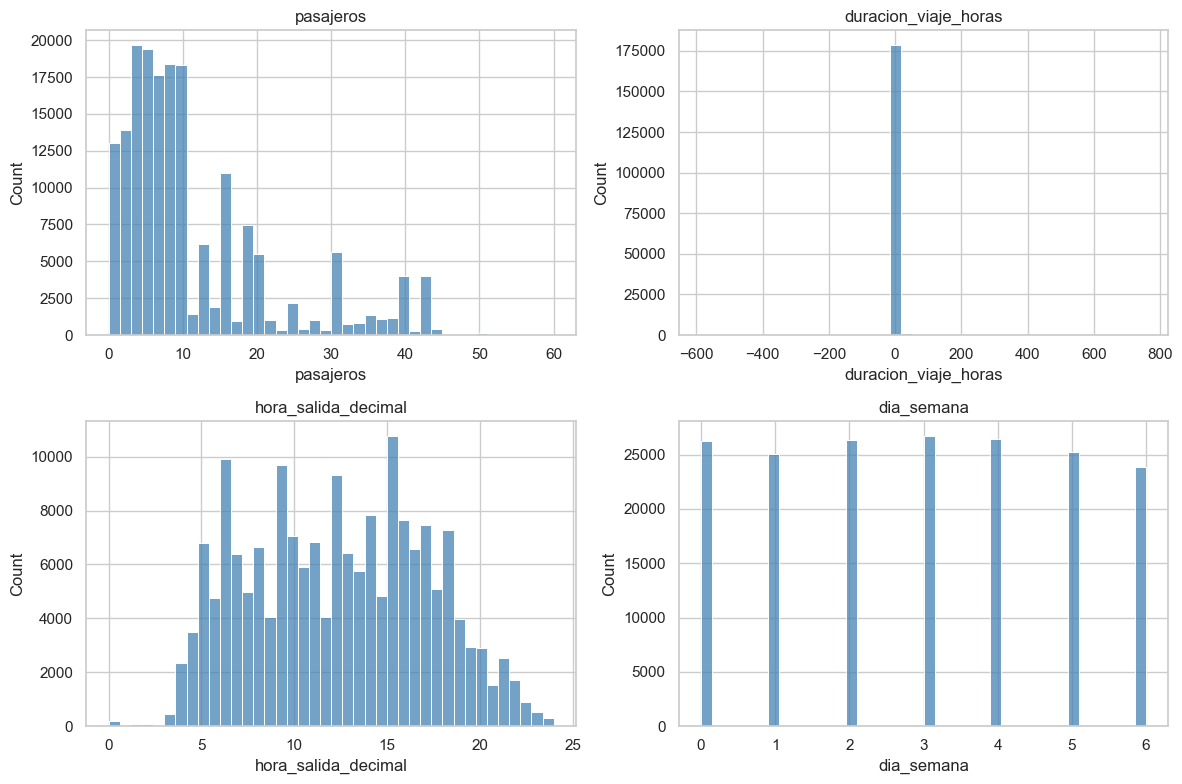

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[c].dropna(), bins=40, ax=ax, color="steelblue")
    ax.set_title(c)
plt.tight_layout()
plt.show()


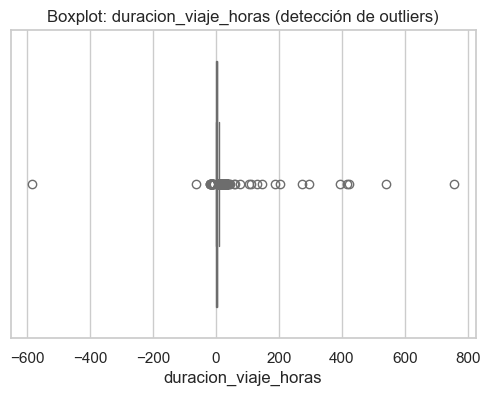

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["duracion_viaje_horas"], color="salmon")
plt.title("Boxplot: duracion_viaje_horas (detección de outliers)")
plt.show()


In [21]:
# Regla del IQR para cuantificar outliers/valores imposibles en el objetivo
q1, q3 = df["duracion_viaje_horas"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

n_negativas = (df["duracion_viaje_horas"] < 0).sum()
n_outliers = ((df["duracion_viaje_horas"] < lim_inf) | (df["duracion_viaje_horas"] > lim_sup)).sum()

print(f"Duraciones negativas (posible error de captura): {n_negativas:,} ({n_negativas/len(df)*100:.3f}%)")
print(f"Límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}] horas")
print(f"Filas fuera de esos límites: {n_outliers:,} ({n_outliers/len(df)*100:.3f}%)")


Duraciones negativas (posible error de captura): 18 (0.010%)
Límites IQR: [-2.93, 8.27] horas
Filas fuera de esos límites: 20,393 (11.329%)


**Lectura:** cualquier duración negativa es evidencia de inconsistencia entre `fecha_salida` y `fecha_llegada` (error de captura) — se documenta aquí, y se decide después (fase de preparación) si esas filas se eliminan. Los valores fuera del rango IQR no son necesariamente errores (pueden ser viajes largos reales, ej. rutas interdepartamentales) — se documenta el conteo, sin eliminar nada todavía.


## Paso 8 — Correlaciones (*correlations*)

Matriz de correlación de Pearson entre las 4 variables numéricas, incluyendo el objetivo.


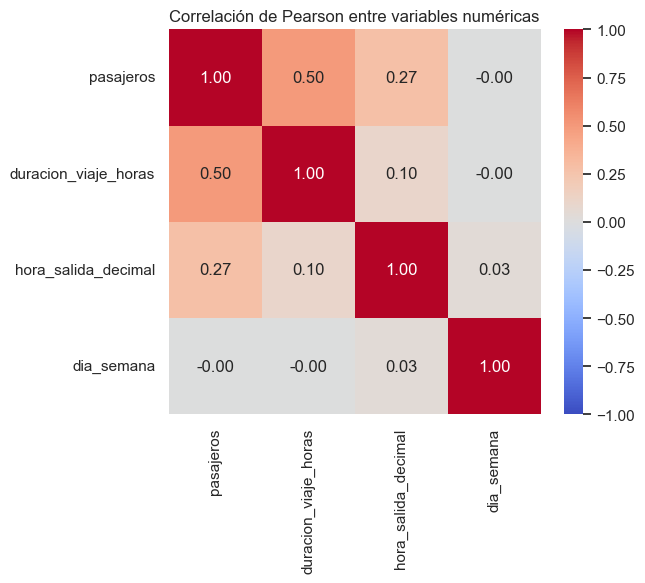

,pasajeros,duracion_viaje_horas,hora_salida_decimal,dia_semana
pasajeros,1.000000,0.499761,0.273728,-0.001183
duracion_viaje_horas,0.499761,1.000000,0.099418,-0.004881
hora_salida_decimal,0.273728,0.099418,1.000000,0.032996
dia_semana,-0.001183,-0.004881,0.032996,1.000000


In [22]:
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación de Pearson entre variables numéricas")
plt.show()
corr


**Cómo leer esto:** valores cercanos a 1 o -1 indican relación lineal fuerte; cercanos a 0, relación lineal débil (no descarta relación no lineal). Correlación no implica causalidad. Si `hora_salida_decimal` o `dia_semana` muestran una correlación apreciable con `duracion_viaje_horas`, es una señal de que el horario/día de salida es relevante para predecir la duración — coherente con la intuición de tráfico y hora pico.

Pearson solo cubre numéricas. Para las categóricas (`empresa`, `ruta_origen`, `clase_veh_culo`, etc.) se complementa con un boxplot del objetivo agrupado por categoría:


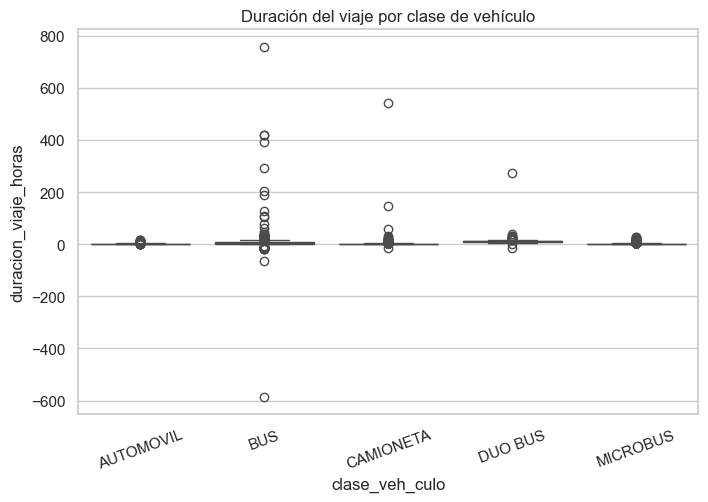

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="clase_veh_culo", y="duracion_viaje_horas")
plt.title("Duración del viaje por clase de vehículo")
plt.xticks(rotation=20)
plt.show()


# Resumen — qué queda para la fase de preparación de datos (no se decide aquí)

Con la evidencia recogida en este notebook, en la siguiente etapa (preparación de datos) se decidirá:

1. **Eliminar `estado`** — confirmado en el Paso 4: varianza cero (solo "LLEGADA"/"Llegada", inconsistencia de mayúsculas).
2. **Eliminar `ruta_destino`** — confirmado en el Paso 4: constante ("MEDELLIN" en el 100% de las filas), hallazgo nuevo no anticipado antes de este notebook.
3. **Normalizar mayúsculas** en `nombre_sucursal` (confirmado: son 2 terminales reales, Norte y Sur, no 1 como se sospechaba) y en `subregi_n` (confirmado: 5 subregiones reales, no 10).
4. **Qué hacer con `fecha_hora_salida_origen` como predictora independiente** (imputar, indicador binario, o descartar) — el patrón de sus nulos ya se confirmó como MAR, no MCAR (Paso 5: depende del año). Nota: su uso *dentro* de la fórmula de `duracion_viaje_horas`/`hora_salida_decimal` (Paso 6) ya está resuelto con el `fillna` — esta decisión pendiente es aparte, sobre si además se deja como columna propia del modelo.
5. Agrupar categorías raras en `ruta_origen` (375 categorías) o `empresa` (137 categorías) si aplica.
6. **Filtrar filas con `duracion_viaje_horas` inválida** — confirmado en el Paso 7: 18 filas negativas (0.010%) y valores extremos tipo -585.9/757.6 horas, claramente errores de captura (no viajes reales).
7. Redundancia entre numéricas, según la matriz de correlación (Paso 8) — `pasajeros` y `duracion_viaje_horas` muestran la correlación más alta (~0.50).
8. Confirmación final de la lista de predictoras.

Este notebook no modifica ni descarta ninguna columna — solo explora y documenta evidencia.
